# Trial 3 Explanation

Now since the focus moves to only the post-COVID years.

In [1]:
import os
import joblib
import warnings
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
from google.colab import files
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.metrics import silhouette_score
from sklearn.linear_model import ElasticNetCV
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Open a file upload dialog
uploaded = files.upload()

Saving Cleaned Dataset.csv to Cleaned Dataset.csv


In [3]:
dataset = pd.read_csv("Cleaned Dataset.csv")

In [4]:
dataset.head()

,Country,Year,BEV Percentage (Total Number Of Registrations),GDP,CPI,EG,Recharging Points,AC Recharging Speed (km/h),DC Recharging Speed (km/h),Available,Battery Capacity,Real Range,Purchase price (EUR),Log_BEV Percentage (Total Number Of Registrations),Log_Recharging Points,Log_GDP,Log_CPI,Log_EG,Log_Available,Log_AC Recharging Speed (km/h)
0,Austria,2020,6.41,380317.9,1.381911,-1.6,26797.0,39.325301,403.164557,97.000000,57.761446,286.200000,38311.380000,2.002830,10.196083,12.848765,0.867903,NaN,4.584967,3.696979
1,Austria,2021,13.92,406231.5,2.766667,2.0,39904.0,40.904348,493.391304,168.000000,64.046957,308.730000,40745.010000,2.702703,10.594257,12.914681,1.326190,1.098612,5.129899,3.735390
2,Austria,2022,15.70,449382.2,8.546870,2.7,61393.0,49.314815,594.259259,253.000000,73.787037,345.440000,43874.270000,2.815409,11.025067,13.015631,2.256213,1.308333,5.537334,3.918300
3,Austria,2023,19.91,477837.3,7.814134,0.8,76773.0,70.307692,649.230769,371.000000,79.230769,379.510785,45999.050000,3.040228,11.248621,13.077028,2.176357,0.587787,5.918894,4.267004
4,Austria,2024,17.58,494087.6,2.937916,0.1,102562.0,92.176355,744.736940,551.323143,88.123464,416.941976,48874.922228,2.922086,11.538233,13.110470,1.370652,0.095310,6.314133,4.534494


In [5]:
dataset.columns

Index(['Country', 'Year', 'BEV Percentage (Total Number Of Registrations)',
       'GDP', 'CPI', 'EG', 'Recharging Points', 'AC Recharging Speed (km/h)',
       'DC Recharging Speed (km/h)', 'Available', 'Battery Capacity',
       'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_Recharging Points', 'Log_GDP', 'Log_CPI', 'Log_EG',
       'Log_Available', 'Log_AC Recharging Speed (km/h)'],
      dtype='object')

# Feature Selection

In [6]:
# Split the dataset into train and test data
train = dataset[dataset['Year'].between(2020, 2024)].copy()
test = dataset[dataset['Year'] >= 2025].copy()

In [7]:
features = [
    'DC Recharging Speed (km/h)',
    'Log_Recharging Points',
    'Real Range',
    'Purchase price (EUR)',
    'Log_Available',
    'Log_AC Recharging Speed (km/h)',
    'Battery Capacity',
    'Log_GDP',
    'Log_CPI',
    'Log_EG'
]

**1. Heat Maps with Pearson Correlation**

Helps in understanding correlation of the features pre-covid.

Correlation of selected features with Log_BEV Percentage (Total Number Of Registrations) on years from 2020 - 2024:

Log_Recharging Points             0.628022
Log_Available                     0.483007
DC Recharging Speed (km/h)        0.477464
Purchase price (EUR)              0.477432
Battery Capacity                  0.474365
Real Range                        0.471754
Log_AC Recharging Speed (km/h)    0.447010
Log_GDP                           0.234884
Log_CPI                           0.151266
Log_EG                            0.110082
Name: Log_BEV Percentage (Total Number Of Registrations), dtype: float64


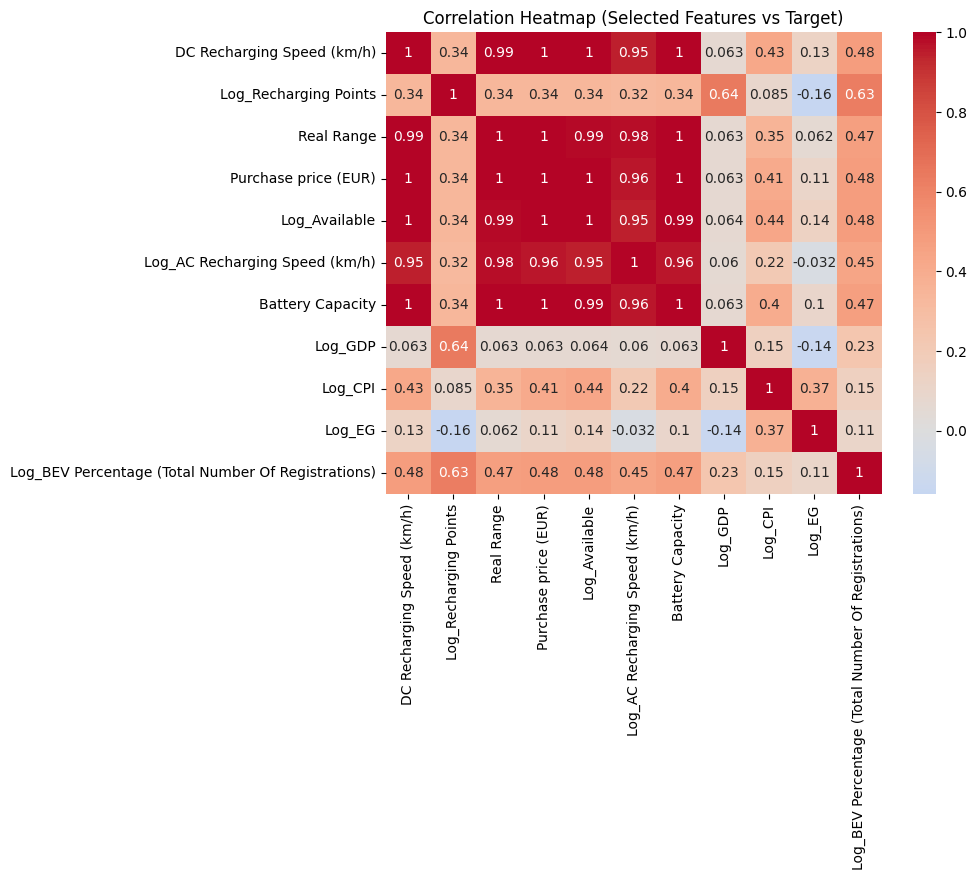

In [8]:
# Define the target
target = 'Log_BEV Percentage (Total Number Of Registrations)'

# Compute correlation only for selected features + target
corr = train[features + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)

# Drop the target itself if it appears
corr = corr.drop(labels=[target], errors='ignore')

# Display correlations
print("Correlation of selected features with Log_BEV Percentage (Total Number Of Registrations) on years from 2020 - 2024:\n")
print(corr)

# Visualize heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train[features + [target]].corr(numeric_only=True),
            annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Selected Features vs Target)")
plt.show()

**2. Multicollinearity**

Removal of redundant features

In [9]:
train_features = dataset[features].dropna().reset_index(drop=True)

vif_data = pd.DataFrame()
vif_data['Feature'] = train_features.columns
vif_data['VIF'] = [variance_inflation_factor(train_features.values, i) for i in range(train_features.shape[1])]

# Print
pd.set_option('display.float_format', '{:.2f}'.format)
print(vif_data)

                          Feature        VIF
0      DC Recharging Speed (km/h)  156187.87
1           Log_Recharging Points       2.41
2                      Real Range 3165985.87
3            Purchase price (EUR) 2008615.57
4                   Log_Available  551093.03
5  Log_AC Recharging Speed (km/h)  959742.81
6                Battery Capacity 3209705.95
7                         Log_GDP       2.16
8                         Log_CPI       3.86
9                          Log_EG       1.53


**3. Principal Component Analysis (PCA)**

To reduce the dimensions and deal with multicollinearity. This also will help us resolve the conflict of high correlation with sales but also high VIF.

**Refer paper : A Tutorial on Principal Component Analysisn to understand the PCA concept**

## Mathematics For PCA

**Step 1: Covariance Matrix**  
Calculates the covariance matrix for the features to see the relationship among themselves. Since we also have average features like "Real Range" and "Battery Capacity" which go hand in hand as verfied previously using heatmap and VIF.

**Step 2: Eigen Value decomposition and determine Eigen Vectors**
Formula: determinant|(A - $\lambda$.I)| = 0

**Step 3: Normalise the Eigen Vectors**
Point to remember: Discarding the eigenvector v2 and so on, will reduce dimensionality leading to loss of information. Therefore here we used Elbow Method to get the significant eigen vectors to prevent this.

**Step 4: Find the Principal Components**
Here,  the aim is to use the feature vector formed using the eigenvectors of the covariance matrix, to reorient the data from the original axes to the ones represented by the principal components (hence the name Principal Components Analysis).

Formula: Final Dataset = Feature Vector (Step 3) * Normalised Original Dataset (Step 3)

In [10]:
# Check which columns have NaNs and how many
print("Missing Values Per Column on Train data (2020-2024)")
print(train[features].isna().sum())

print("\nMissing Values Per Column Test data (2025)")
print(test[features].isna().sum())

Missing Values Per Column on Train data (2020-2024)
DC Recharging Speed (km/h)         0
Log_Recharging Points              1
Real Range                         0
Purchase price (EUR)               0
Log_Available                      0
Log_AC Recharging Speed (km/h)     0
Battery Capacity                   0
Log_GDP                            0
Log_CPI                            1
Log_EG                            22
dtype: int64

Missing Values Per Column Test data (2025)
DC Recharging Speed (km/h)        0
Log_Recharging Points             0
Real Range                        0
Purchase price (EUR)              0
Log_Available                     0
Log_AC Recharging Speed (km/h)    0
Battery Capacity                  0
Log_GDP                           0
Log_CPI                           0
Log_EG                            0
dtype: int64


In [11]:
# Checking which rows are empty
print("Missing Log_EG in Train data (2020-2024)")
print(train[train['Log_EG'].isna()].reset_index()[['Country', 'Year', 'Log_EG']])

Missing Log_EG in Train data (2020-2024)
           Country  Year  Log_EG
0          Austria  2020     NaN
1         Bulgaria  2020     NaN
2          Croatia  2020     NaN
3   Czech Republic  2020     NaN
4          Denmark  2020     NaN
5          Estonia  2020     NaN
6          Finland  2020     NaN
7          Finland  2024     NaN
8           Greece  2020     NaN
9          Hungary  2020     NaN
10         Hungary  2024     NaN
11         Ireland  2020     NaN
12           Italy  2020     NaN
13          Latvia  2021     NaN
14          Latvia  2024     NaN
15       Lithuania  2020     NaN
16        Portugal  2020     NaN
17         Romania  2020     NaN
18         Romania  2023     NaN
19        Slovakia  2020     NaN
20           Spain  2020     NaN
21          Sweden  2020     NaN


In [12]:
features_to_impute = ['Log_Recharging Points', 'Log_EG', 'Log_CPI']

# Compute per-country median from train
train_country_medians = {}
train_global_medians = {}

for col in features_to_impute:
    train_country_medians[col] = train.groupby('Country')[col].median()
    train_global_medians[col] = train[col].median()

def robust_impute(df, country_medians, global_medians):
    df_copy = df.copy()
    for col in features_to_impute:

        # Impute per-country median
        df_copy[col] = df_copy[col].fillna(df_copy['Country'].map(country_medians[col]))

        # Fallback to global median if still NaN
        df_copy[col] = df_copy[col].fillna(global_medians[col])
    return df_copy

# Apply to train and test
X_train_imputed = robust_impute(train, train_country_medians, train_global_medians)
X_test_imputed = robust_impute(test, train_country_medians, train_global_medians)

In [13]:
# Verfication
print("Missing Values Per Column on Train data (2020-2024)")
print(X_train_imputed[features].isna().sum())

print("\nMissing Values Per Column Test data (2025)")
print(X_test_imputed[features].isna().sum())

Missing Values Per Column on Train data (2020-2024)
DC Recharging Speed (km/h)        0
Log_Recharging Points             0
Real Range                        0
Purchase price (EUR)              0
Log_Available                     0
Log_AC Recharging Speed (km/h)    0
Battery Capacity                  0
Log_GDP                           0
Log_CPI                           0
Log_EG                            0
dtype: int64

Missing Values Per Column Test data (2025)
DC Recharging Speed (km/h)        0
Log_Recharging Points             0
Real Range                        0
Purchase price (EUR)              0
Log_Available                     0
Log_AC Recharging Speed (km/h)    0
Battery Capacity                  0
Log_GDP                           0
Log_CPI                           0
Log_EG                            0
dtype: int64


In [14]:
# Standard Scaling to bring everything in one unit after imputing the dataset
# Only take numeric features
X_train_numeric = X_train_imputed[features]
X_test_numeric = X_test_imputed[features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

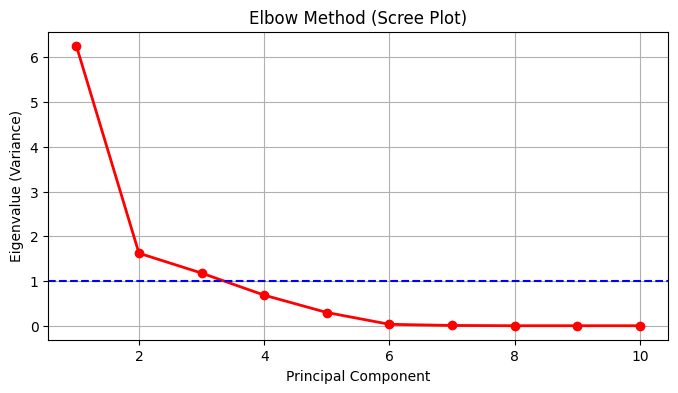

In [15]:
# Elbow Method to justify the number of components
pca_full = PCA() # We fit all 10 components first to see the curve
pca_full.fit(X_train_scaled)
eigenvalues = pca_full.explained_variance_

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'ro-', linewidth=2)
plt.axhline(y=1, color='blue', linestyle='--')
plt.title('Elbow Method (Scree Plot)')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Variance)')
plt.grid(True)
plt.show()

The logic here is we have kept only those eigenvalues which above the "elbow" (or above lambda = 1).

Mathematically discarding the Eigenvectors v4 to v10.

In [16]:
# PCA
principal_components = 3 # Based on the elbow method for not missing out on any features
pca = PCA(n_components=principal_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

We calculate the covariance matrix and the Eigen values on the pre-covid dataset.
1. This identifies relationship between variables like Real Range and Battery Capacity.
2. The Eigenvalues tell you which patterns were the strongest before the pandemic. For example, if "GDP" was the biggest driver of variance in 2015, the Eigenvector associated with the largest $\lambda$ will point toward GDP.

In [17]:
# Convert to Final Dataset for your Prediction Model
pc_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

X_train_final = pd.DataFrame(X_train_pca, columns=pc_columns, index=train.index)
X_test_final = pd.DataFrame(X_test_pca, columns=pc_columns, index=test.index)

In [18]:
# Define target
y_train = train['Log_BEV Percentage (Total Number Of Registrations)']
y_test = test['Log_BEV Percentage (Total Number Of Registrations)']

print(f"{len(features)} features reduced to {len(pc_columns)} Principal Components.")
print(f"Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

10 features reduced to 3 Principal Components.
Variance Explained: 89.91%


**For Train:** Python takes the 2020–2024 data and multiplies it by the top 3 Eigenvectors to get the X_train_final coordinates.

**For Test:** Code does not solve $|A - lambda I| = 0 for the Test set. Instead, it takes the Feature Vector (Eigenvectors) discovered in the Training set and multiplies it by the 2025 data. This prevents data leakage.

In [19]:
# Check which PC is the strongest predictor of sales
pc_correlation = X_train_final.corrwith(y_train)
print("Correlation of Principal Components with BEV Sales:")
print(pc_correlation.sort_values(ascending=False))

Correlation of Principal Components with BEV Sales:
PC1   0.50
PC2   0.30
PC3   0.09
dtype: float64


In [20]:
# Features along with their weights in each principal component columns explaining their variance.
loadings_table = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=features
)

# Display the final table
print("Loading factors of the parameters selected (Feature Weights)")
print(loadings_table.round(4))

Loading factors of the parameters selected (Feature Weights)
                                PC1   PC2   PC3
DC Recharging Speed (km/h)     0.40 -0.06 -0.01
Log_Recharging Points          0.15  0.64  0.07
Real Range                     0.40 -0.05 -0.09
Purchase price (EUR)           0.40 -0.05 -0.04
Log_Available                  0.40 -0.06 -0.01
Log_AC Recharging Speed (km/h) 0.38 -0.03 -0.20
Battery Capacity               0.40 -0.05 -0.04
Log_GDP                        0.05  0.69  0.29
Log_CPI                        0.17 -0.06  0.62
Log_EG                         0.02 -0.31  0.69


In [21]:
# To confirm that all the principal components are independent of each other.
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_final.columns

# Calculate VIF for each Principal Component
vif_data["VIF"] = [variance_inflation_factor(X_train_final.values, i)
                   for i in range(len(X_train_final.columns))]

print("VIF for Principal Components")
print(vif_data)

VIF for Principal Components
  Feature  VIF
0     PC1 1.00
1     PC2 1.00
2     PC3 1.00


In [22]:
# Saving the PCA model
# Define filenames
csv_files = ['X_train_pca.csv', 'X_test_pca.csv', 'y_train.csv', 'y_test.csv']
pkl_file = 'pca_processors.pkl'

# Save the processed Datasets
X_train_final.to_csv(csv_files[0], index=True)
X_test_final.to_csv(csv_files[1], index=True)
y_train.to_csv(csv_files[2], index=True)
y_test.to_csv(csv_files[3], index=True)

# Save the PCA
pca_processing_tools = {
    'country_medians': train_country_medians,
    'scaler': scaler,
    'pca_model': pca,
    'feature_names': features
}
joblib.dump(pca_processing_tools, pkl_file)

# Just to be sure print the exact file locations
print(f"Folder Location: {os.getcwd()}")
print("-" * 30)

for file in csv_files + [pkl_file]:
    full_path = os.path.abspath(file)
    print(f"Saved: {file}")
    print(f"Full Path: {full_path}\n")

Folder Location: /content
------------------------------
Saved: X_train_pca.csv
Full Path: /content/X_train_pca.csv

Saved: X_test_pca.csv
Full Path: /content/X_test_pca.csv

Saved: y_train.csv
Full Path: /content/y_train.csv

Saved: y_test.csv
Full Path: /content/y_test.csv

Saved: pca_processors.pkl
Full Path: /content/pca_processors.pkl



# Clustering

In [23]:
# Load PCA tools and feature definitions
tools = joblib.load("pca_processors.pkl")

scaler = tools['scaler']
pca = tools['pca_model']
country_medians = tools['country_medians']
features = tools['feature_names']

Understanding train data and test covid

In [24]:
# Split the dataset
train_data = dataset[dataset['Year'].between(2020, 2024)].copy()
test_data = dataset[dataset['Year'] >= 2025].copy()

In [25]:
# Aggregate numeric features per country
train_country = train_data.groupby('Country')[features].mean(numeric_only=True)
test_country = test_data.groupby('Country')[features].mean(numeric_only=True)

print(f"Train dataset shape: {train_country.shape}")
print(f"Test dataset shape: {test_country.shape}")

Train dataset shape: (27, 10)
Test dataset shape: (27, 10)


1. Each country now appears once per period.
2. Each feature represents that country’s average condition during the period.

In [26]:
# Apply the same scaling and PCA
X_pre_scaled = scaler.transform(train_country)
X_post_scaled = scaler.transform(test_country)

X_pre_pca = pca.transform(X_pre_scaled)
X_post_pca = pca.transform(X_post_scaled)

print(f"PCA-transformed shapes: Train={X_pre_pca.shape}, Test={X_post_pca.shape}")

PCA-transformed shapes: Train=(27, 3), Test=(27, 3)


## 1. K-Means

**Refer paper: Analysis of Techniques for Selecting Appropriate Number of Clusters in k-means Clustering Algorithm** to cite why I chose these 2 methods.

Elbow Method

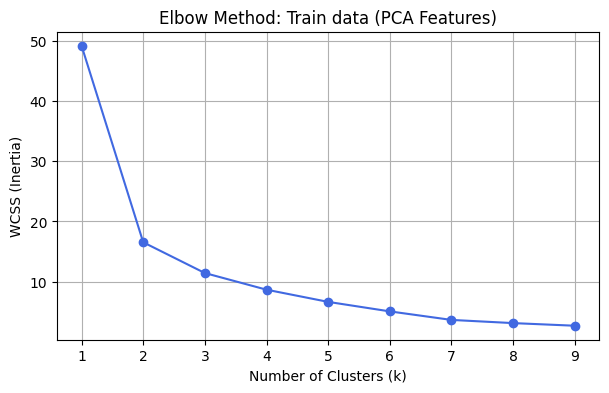

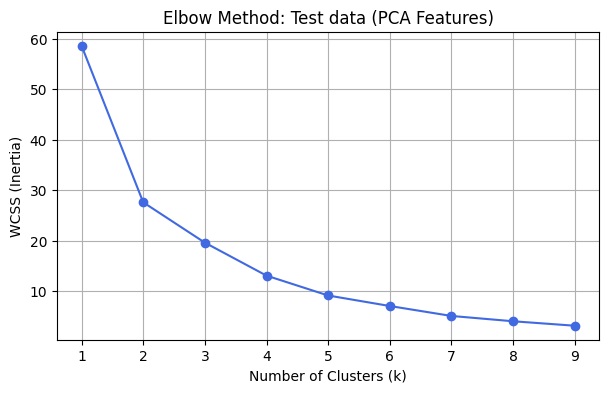

In [27]:
# Elbow Method (to find optimal k)
def plot_elbow(X, label):
    inertia = []
    K_range = range(1, 10)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)
    plt.figure(figsize=(7, 4))
    plt.plot(K_range, inertia, 'o-', color='royalblue')
    plt.title(f'Elbow Method: {label}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS (Inertia)')
    plt.grid(True)
    plt.show()

plot_elbow(X_pre_pca, "Train data (PCA Features)")
plot_elbow(X_post_pca, "Test data (PCA Features)")

Use of SILHOUETTE method to verify the #clusters in eblow method

**This is the validation method to the elbow method.**

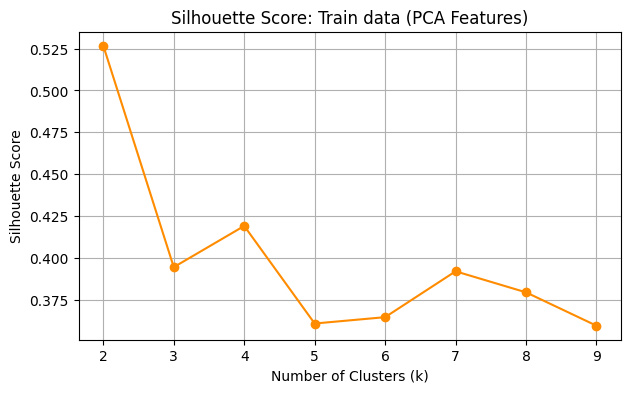

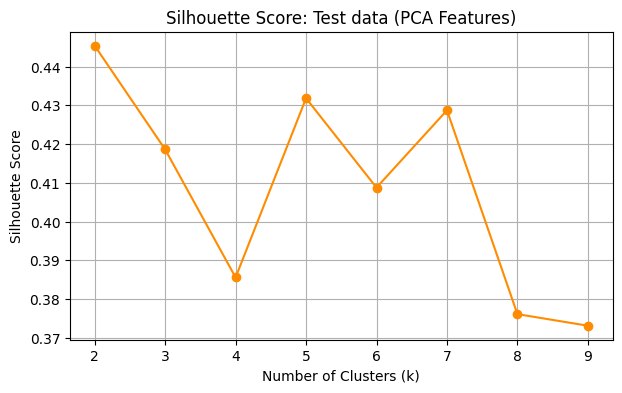

In [28]:
# Silhouette Method (to validate optimal k)
def plot_silhouette(X, label):
    sil_scores = []
    K_range = range(2, 10)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)
    plt.figure(figsize=(7, 4))
    plt.plot(K_range, sil_scores, 'o-', color='darkorange')
    plt.title(f'Silhouette Score: {label}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

plot_silhouette(X_pre_pca, "Train data (PCA Features)")
plot_silhouette(X_post_pca, "Test data (PCA Features)")

In [29]:
# Final Clustering
n_clusters = 2

kmeans_pre = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_post = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

train_country['Cluster'] = kmeans_pre.fit_predict(X_pre_pca)
test_country['Cluster'] = kmeans_post.fit_predict(X_post_pca)

In [30]:
# Compare cluster memberships pre vs post COVID
cluster_compare = train_country[['Cluster']].rename(columns={'Cluster': 'Train_Cluster'})
cluster_compare['Test_Cluster'] = test_country['Cluster']
print(cluster_compare)

                Train_Cluster  Test_Cluster
Country                                    
Austria                     0             0
Belgium                     0             0
Bulgaria                    1             1
Croatia                     1             1
Cyprus                      1             1
Czech Republic              0             0
Denmark                     0             0
Estonia                     1             1
Finland                     1             0
France                      0             0
Germany                     0             0
Greece                      1             0
Hungary                     0             0
Ireland                     1             1
Italy                       0             0
Latvia                      1             1
Lithuania                   1             1
Luxembourg                  1             1
Malta                       1             1
Netherlands                 0             0
Poland                      0   

In [31]:
# Print which countries changed clusters
print("\nCountries that changed clusters from Train to Test Cluster:\n")
for c in cluster_compare.index:
    pre_c = cluster_compare.loc[c, 'Train_Cluster']
    post_c = cluster_compare.loc[c, 'Test_Cluster']
    if pre_c != post_c:
        print(f"  - {c}: {pre_c} ---> {post_c}")


Countries that changed clusters from Train to Test Cluster:

  - Finland: 1 ---> 0
  - Greece: 1 ---> 0
  - Portugal: 1 ---> 0


In [32]:
# Print which stable countries
stable_count = 0

for c in cluster_compare.index:
    pre_c = cluster_compare.loc[c, 'Train_Cluster']
    post_c = cluster_compare.loc[c, 'Test_Cluster']

    # If the clusters are the same
    if pre_c == post_c:
        print(f"  - {c}: Stayed in Cluster {pre_c}")
        stable_count += 1

  - Austria: Stayed in Cluster 0
  - Belgium: Stayed in Cluster 0
  - Bulgaria: Stayed in Cluster 1
  - Croatia: Stayed in Cluster 1
  - Cyprus: Stayed in Cluster 1
  - Czech Republic: Stayed in Cluster 0
  - Denmark: Stayed in Cluster 0
  - Estonia: Stayed in Cluster 1
  - France: Stayed in Cluster 0
  - Germany: Stayed in Cluster 0
  - Hungary: Stayed in Cluster 0
  - Ireland: Stayed in Cluster 1
  - Italy: Stayed in Cluster 0
  - Latvia: Stayed in Cluster 1
  - Lithuania: Stayed in Cluster 1
  - Luxembourg: Stayed in Cluster 1
  - Malta: Stayed in Cluster 1
  - Netherlands: Stayed in Cluster 0
  - Poland: Stayed in Cluster 0
  - Romania: Stayed in Cluster 0
  - Slovakia: Stayed in Cluster 1
  - Slovenia: Stayed in Cluster 1
  - Spain: Stayed in Cluster 0
  - Sweden: Stayed in Cluster 0


In [33]:
# Check mean PC scores for each cluster Train data and Test data

# Merge the PCA values back into our country summaries
pre_analysis = pd.DataFrame(X_pre_pca, columns=['PC1', 'PC2', 'PC3'], index=train_country.index)
pre_analysis['Cluster'] = train_country['Cluster']

post_analysis = pd.DataFrame(X_post_pca, columns=['PC1', 'PC2', 'PC3'], index=test_country.index)
post_analysis['Cluster'] = test_country['Cluster']

# Print the Centroids characteristics as per the PCA
print("Train Data (2020-2024) Cluster Centroids (Mean PCA Scores)")
print(pre_analysis.groupby('Cluster').mean())
print()
print("Test Data (2025) Cluster Centroids (Mean PCA Scores)")
print(post_analysis.groupby('Cluster').mean())

Train Data (2020-2024) Cluster Centroids (Mean PCA Scores)
          PC1   PC2   PC3
Cluster                  
0        0.16  1.11  0.23
1       -0.15 -1.03 -0.22

Test Data (2025) Cluster Centroids (Mean PCA Scores)
         PC1   PC2   PC3
Cluster                 
0       5.56  0.83 -1.24
1       5.31 -1.34 -1.26


In [34]:
# Preparing the data for plotting by ensuring PC scores and Clusters are aligned

# List of unique countries in the correct order
pre_countries_list = train_country.index
post_countries_list = test_country.index

# Create DataFrames for plotting using the PCA results
pre_plot_data = pd.DataFrame(X_pre_pca, columns=['PC1', 'PC2', 'PC3'], index=pre_countries_list)
pre_plot_data['Cluster'] = train_country['Cluster']

post_plot_data = pd.DataFrame(X_post_pca, columns=['PC1', 'PC2', 'PC3'], index=post_countries_list)
post_plot_data['Cluster'] = test_country['Cluster']

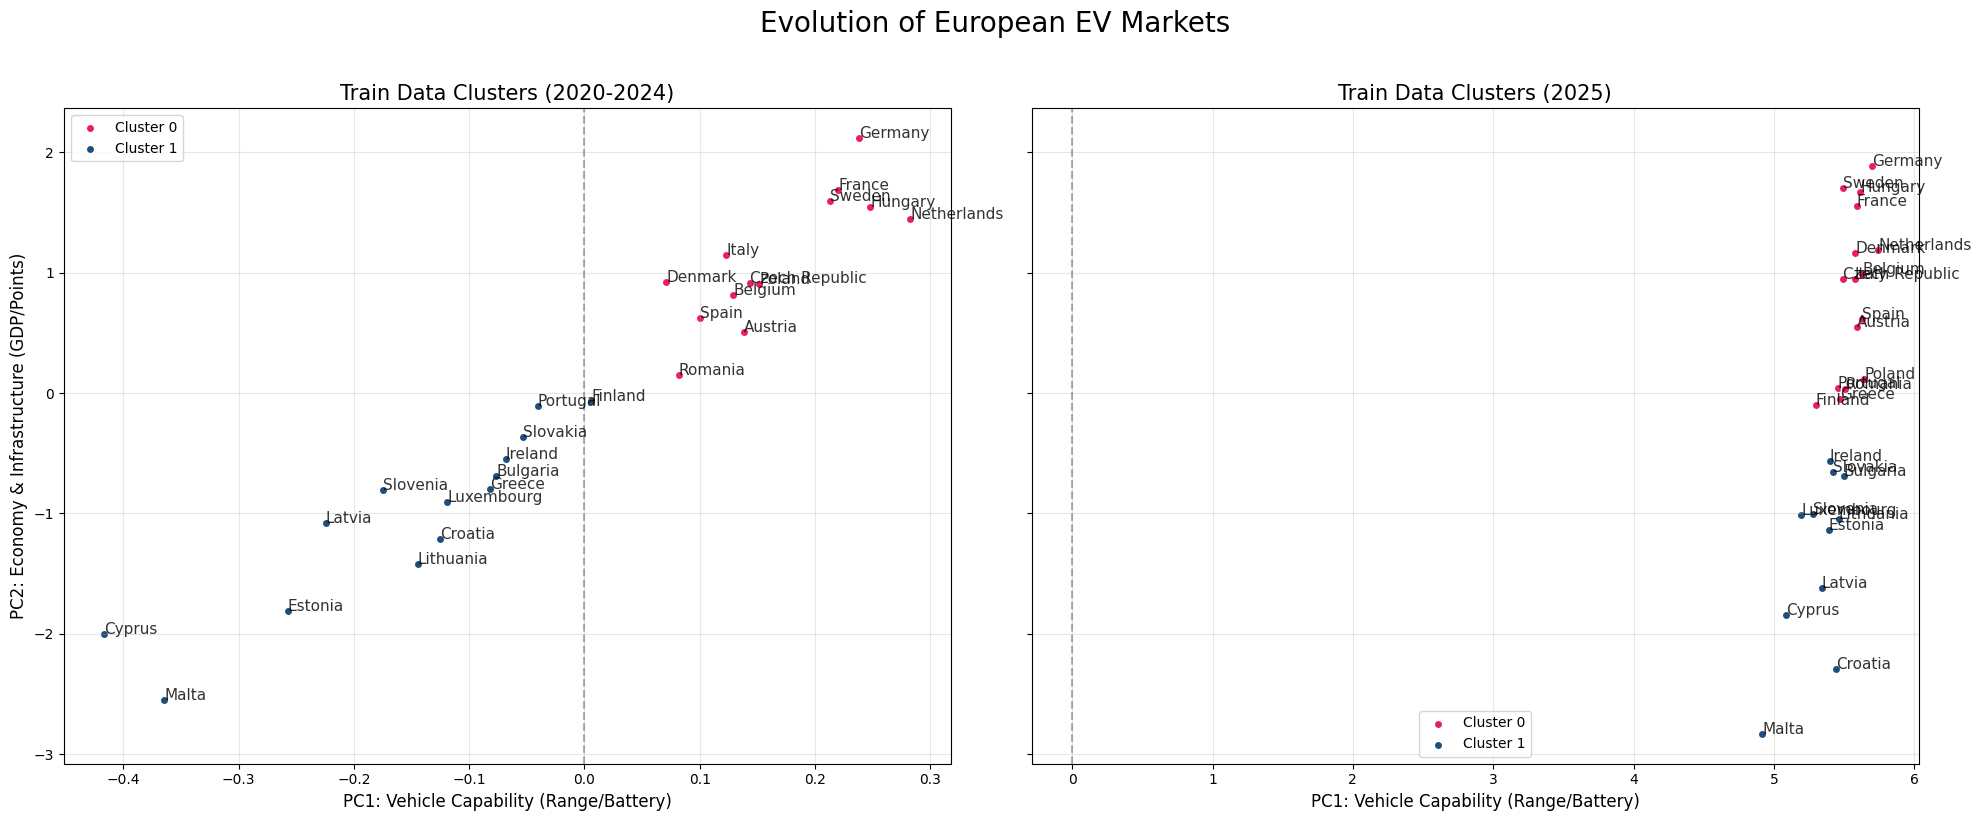

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

cluster_colors = {0: "#E91E63", 1: "#1f4e79"}

# Test Data
for cluster in [0, 1]:
    subset = pre_plot_data[pre_plot_data['Cluster'] == cluster]
    ax1.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', edgecolors='white', color=cluster_colors[cluster])

for country in pre_plot_data.index:
    row = pre_plot_data.loc[country]
    ax1.text(row['PC1'], row['PC2'], country, fontsize=11, alpha=0.8)

ax1.set_title('Train Data Clusters (2020-2024)', fontsize=15)
ax1.set_xlabel('PC1: Vehicle Capability (Range/Battery)', fontsize=12)
ax1.set_ylabel('PC2: Economy & Infrastructure (GDP/Points)', fontsize=12)
ax1.axvline(0, color='black', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Post-COVID
for cluster in [0, 1]:
    subset = post_plot_data[post_plot_data['Cluster'] == cluster]
    ax2.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', edgecolors='white', color=cluster_colors[cluster])

for country in post_plot_data.index:
    row = post_plot_data.loc[country]
    ax2.text(row['PC1'], row['PC2'], country, fontsize=11, alpha=0.8)

ax2.set_title('Train Data Clusters (2025)', fontsize=15)
ax2.set_xlabel('PC1: Vehicle Capability (Range/Battery)', fontsize=12)
ax2.axvline(0, color='black', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('Evolution of European EV Markets', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

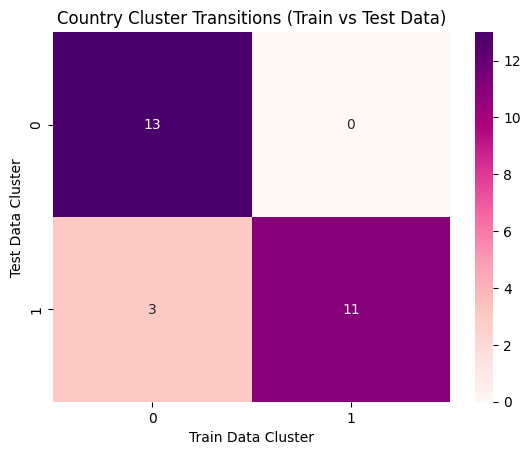

In [36]:
# Heatmap to visualize cluster transitions
ct = pd.crosstab(cluster_compare['Train_Cluster'], cluster_compare['Test_Cluster'])
sns.heatmap(ct, annot=True, fmt='d', cmap='RdPu')
plt.title('Country Cluster Transitions (Train vs Test Data)')
plt.xlabel('Train Data Cluster')
plt.ylabel('Test Data Cluster')
plt.show()

## For Geopandas Visualization

In [37]:
# Read Europe shapefile from GeoJSON (countries only)
url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
world = gpd.read_file(url)

print(world.columns)

Index(['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry'], dtype='object')


In [38]:
# List of European countries
europe_countries = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Netherlands", "Poland", "Portugal", "Romania", "Slovakia", "Slovenia",
    "Spain", "Sweden"
]

# Replace 'name' with whatever column actually contains country names
europe = world[world['name'].isin(europe_countries)]

In [39]:
geo_data = europe.merge(dataset, left_on='name', right_on='Country', how='left')
geo_data = gpd.GeoDataFrame(geo_data, geometry='geometry')

In [40]:
print(geo_data.columns)

Index(['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry', 'Country',
       'Year', 'BEV Percentage (Total Number Of Registrations)', 'GDP', 'CPI',
       'EG', 'Recharging Points', 'AC Recharging Speed (km/h)',
       'DC Recharging Speed (km/h)', 'Available', 'Battery Capacity',
       'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_Recharging Points', 'Log_GDP', 'Log_CPI', 'Log_EG',
       'Log_Available', 'Log_AC Recharging Speed (km/h)'],
      dtype='object')


In [41]:
# Create Train Data summary
# We reset the index to turn 'Country' into a column and rename 'Cluster' to 'KMeans_Cluster'
pre_covid_summary = pre_plot_data.reset_index().rename(columns={
    'index': 'Country',
    'Cluster': 'KMeans_Cluster'
})[['Country', 'KMeans_Cluster']]

# Create Test Data summary
post_covid_summary = post_plot_data.reset_index().rename(columns={
    'index': 'Country',
    'Cluster': 'KMeans_Cluster'
})[['Country', 'KMeans_Cluster']]

print("Train Data K-Means")
display(pre_covid_summary.head())
print()
print("Test Data K-Means")
display(post_covid_summary.head())

Train Data K-Means


,Country,KMeans_Cluster
0,Austria,0
1,Belgium,0
2,Bulgaria,1
3,Croatia,1
4,Cyprus,1



Test Data K-Means


,Country,KMeans_Cluster
0,Austria,0
1,Belgium,0
2,Bulgaria,1
3,Croatia,1
4,Cyprus,1


In [42]:
# Create a fresh copy of your main dataset
dataset_clusters = dataset.copy()

# Merge Train Data clusters
dataset_clusters = dataset_clusters.merge(
    pre_covid_summary,
    on='Country',
    how='left'
).rename(columns={'KMeans_Cluster': 'KMeans_Train'})

# Merge Test Data clusters
dataset_clusters = dataset_clusters.merge(
    post_covid_summary,
    on='Country',
    how='left'
).rename(columns={'KMeans_Cluster': 'KMeans_Test'})

print("Merging complete. Columns in dataset_clusters:")
print(dataset_clusters.columns)

Merging complete. Columns in dataset_clusters:
Index(['Country', 'Year', 'BEV Percentage (Total Number Of Registrations)',
       'GDP', 'CPI', 'EG', 'Recharging Points', 'AC Recharging Speed (km/h)',
       'DC Recharging Speed (km/h)', 'Available', 'Battery Capacity',
       'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_Recharging Points', 'Log_GDP', 'Log_CPI', 'Log_EG',
       'Log_Available', 'Log_AC Recharging Speed (km/h)', 'KMeans_Train',
       'KMeans_Test'],
      dtype='object')


In [43]:
geo_data = europe.merge(dataset_clusters, left_on='name', right_on='Country', how='left')
geo_data = gpd.GeoDataFrame(geo_data, geometry='geometry')

In [44]:
print(geo_data.columns.tolist())

['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry', 'Country', 'Year', 'BEV Percentage (Total Number Of Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points', 'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)', 'Log_BEV Percentage (Total Number Of Registrations)', 'Log_Recharging Points', 'Log_GDP', 'Log_CPI', 'Log_EG', 'Log_Available', 'Log_AC Recharging Speed (km/h)', 'KMeans_Train', 'KMeans_Test']


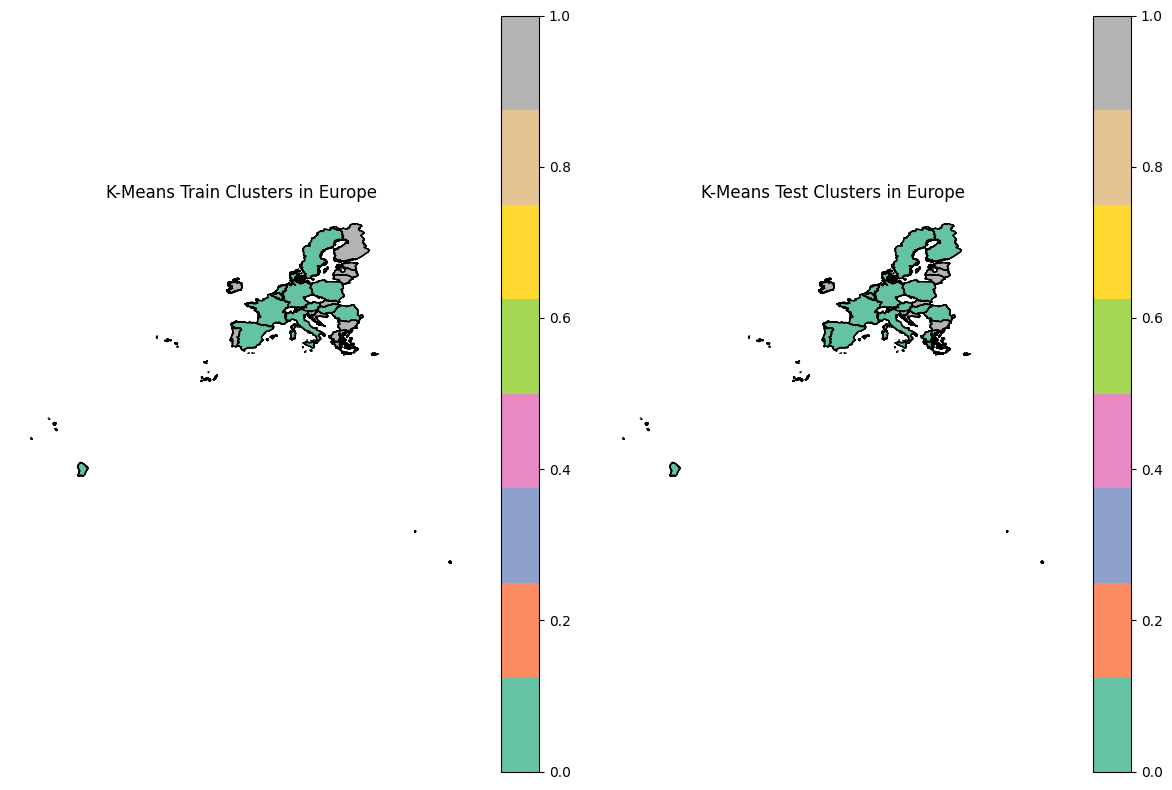

In [45]:
# K-Means: Train and Test

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

geo_data.plot(column='KMeans_Train', cmap='Set2', legend=True, ax=axes[0], edgecolor='black')
axes[0].set_title("K-Means Train Clusters in Europe")
axes[0].axis('off')

geo_data.plot(column='KMeans_Test', cmap='Set2', legend=True, ax=axes[1], edgecolor='black')
axes[1].set_title("K-Means Test Clusters in Europe")
axes[1].axis('off')

plt.tight_layout()
plt.show()